## ٢٠/٩ — تحضير بيانات السلسلة الزمنية

In [18]:
import pandas as pd

df = pd.read_csv("thermal_log.csv")

print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.head())

(2359, 6)
timestamp     object
ms             int64
t_in         float64
h_in         float64
t_out        float64
h_out        float64
dtype: object
timestamp    0
ms           0
t_in         0
h_in         0
t_out        0
h_out        0
dtype: int64
             timestamp     ms  t_in  h_in  t_out  h_out
0  2026-09-03T14:41:35   2040  30.5  44.2   31.8   32.0
1  2026-09-03T14:41:37   4040  30.5  43.2   31.8   32.0
2  2026-09-03T14:41:39   6040  30.5  44.7   31.8   32.0
3  2026-09-03T14:41:41   8040  30.5  44.7   31.8   32.0
4  2026-09-03T14:41:43  10040  30.5  44.7   31.8   32.0


In [19]:
d = df["ms"].diff()

print(d.value_counts().head(10))
print(df[d > 2500][["timestamp", "ms"]])

ms
2000.0    2358
Name: count, dtype: int64
Empty DataFrame
Columns: [timestamp, ms]
Index: []


In [21]:
cols = ["t_in", "h_in", "t_out", "h_out"]
m = df[cols] == -99

print(m.sum())
print(m.any(axis=1).sum())

t_in     87
h_in     87
t_out     1
h_out     1
dtype: int64
88


In [22]:
bad = df["t_in"] == -99
start = bad & ~bad.shift(1, fill_value=False)
blk = start.cumsum()[bad]

print(start.sum())
print(blk.value_counts().sort_index())

3
t_in
1    29
2    29
3    29
Name: count, dtype: int64


In [6]:
ends = bad & ~bad.shift(-1, fill_value=False)
for s, e in zip(df.index[start], df.index[ends]):
    print(df.loc[s-5:e+5, ["ms", "t_in", "h_in"]].drop(df.index[s:e+1]))
    print("-----")

           ms  t_in  h_in
1888  3778040  28.7  50.8
1889  3780040  28.7  50.8
1890  3782040  28.7  50.7
1891  3784040  28.7  50.9
1892  3786040  28.7  51.0
1922  3846040  28.8  51.2
1923  3848040  29.0  49.6
1924  3850040  29.0  49.5
1925  3852040  29.0  49.5
1926  3854040  29.0  49.5
-----
           ms  t_in  h_in
2038  4078040  29.8  48.3
2039  4080040  29.8  48.4
2040  4082040  29.8  48.4
2041  4084040  29.8  48.3
2042  4086040  29.8  48.2
2072  4146040  29.8  48.2
2073  4148040  29.9  48.8
2074  4150040  29.9  48.8
2075  4152040  29.9  48.9
2076  4154040  29.9  48.9
-----
           ms  t_in  h_in
2188  4378040  30.2  48.3
2189  4380040  30.2  49.1
2190  4382040  30.2  49.5
2191  4384040  30.2  49.4
2192  4386040  30.2  49.1
2222  4446040  30.2  48.9
2223  4448040  30.3  49.2
2224  4450040  30.2  49.4
2225  4452040  30.2  49.5
2226  4454040  30.2  49.4
-----


In [7]:
# run with k = 0, 1, 2 (one block at a time)
b = pd.DataFrame({"s": df.index[start], "e": df.index[ends]})

k = 2
s, e = b.loc[k, "s"], b.loc[k, "e"]
print("كتلة", k + 1, "من", s, "إلى", e)
print(df.loc[s-5:s-1, ["t_in", "h_in"]].T)
print(df.loc[e+1:e+5, ["t_in", "h_in"]].T)

كتلة 3 من 2193 إلى 2221
      2188  2189  2190  2191  2192
t_in  30.2  30.2  30.2  30.2  30.2
h_in  48.3  49.1  49.5  49.4  49.1
      2222  2223  2224  2225  2226
t_in  30.2  30.3  30.2  30.2  30.2
h_in  48.9  49.2  49.4  49.5  49.4


In [8]:
cols = ["t_in", "h_in", "t_out", "h_out"]
out = ["t_out", "h_out"]

clean = df.copy()
clean[cols] = clean[cols].replace(-99, float("nan"))

# الخارجي: تعبئة قيمة معزولة فقط بمتوسط جارتيها
clean[out] = clean[out].interpolate(limit=1, limit_area="inside")

# الداخلي: الكتلة + أول قراءة بعدها
bad_in = clean["t_in"].isna()
bad_in = bad_in | bad_in.shift(1, fill_value=False)

# تقطيع القطع السليمة
good = ~bad_in
seg = (good & ~good.shift(1, fill_value=False)).cumsum()
segments = [g for _, g in clean[good].groupby(seg[good])]

print(clean[out].isna().sum())
print(len(segments))
print([len(g) for g in segments])

t_out    0
h_out    0
dtype: int64
4
[1893, 120, 120, 136]


In [9]:
for i, g in enumerate(segments):
    print(i + 1, len(g),
          "t_in:", g["t_in"].min(), g["t_in"].max(),
          "h_in:", g["h_in"].min(), g["h_in"].max())

1 1893 t_in: 25.4 39.1 h_in: 37.0 99.9
2 120 t_in: 29.0 29.8 h_in: 48.2 49.9
3 120 t_in: 29.9 30.2 h_in: 47.8 49.5
4 136 t_in: 30.2 30.4 h_in: 47.4 49.5


In [10]:
p = segments[0]
hi = p["h_in"] >= 95

print(hi.sum())
s_hi = hi & ~hi.shift(1, fill_value=False)
print(s_hi.sum())
print(p.loc[hi, ["t_in", "h_in"]].describe().loc[["min", "max"]])

225
5
     t_in  h_in
min  30.8  95.1
max  39.1  99.9


In [11]:
ev = s_hi.cumsum()[hi]
print(pd.DataFrame({
    "len": ev.value_counts().sort_index(),
    "at_max": (p.loc[hi, "h_in"] >= 99.9).groupby(ev).sum(),
    "start": p.index[s_hi],
}))

      len  at_max  start
h_in                    
1      43      40    306
2      43      40    501
3      43      39    696
4      50      48    890
5      46      44   1071


In [12]:
f = p["t_in"]
d = f.diff(30)
top = d.nlargest(5)

print(pd.DataFrame({
    "rise_60s": top,
    "t_in": f[top.index],
    "h_in": p.loc[top.index, "h_in"],
    "in_hold": hi[top.index],
}))

     rise_60s  t_in  h_in  in_hold
917       7.4  39.1  99.9     True
918       7.3  39.1  99.9     True
919       7.1  39.0  99.9     True
915       7.1  38.8  99.9     True
916       7.1  38.9  99.9     True


In [13]:
train = segments[0]
val = segments[1:]

mu = train["t_in"].mean()
sd = train["t_in"].std()

def norm(g):
    return ((g["t_in"] - mu) / sd).to_numpy()

train_z = norm(train)
val_z = [norm(g) for g in val]

print(round(mu, 2), round(sd, 2))
print(round(train_z.mean(), 3), round(train_z.std(), 3))
for i, z in enumerate(val_z):
    print(i + 2, round(z.min(), 2), round(z.max(), 2))

30.92 2.55
-0.0 1.0
2 -0.76 -0.44
3 -0.4 -0.28
4 -0.28 -0.21


In [14]:
import numpy as np

W = 15

def make_windows(z, W):
    X = [z[i:i+W] for i in range(len(z) - W)]
    y = [z[i+W] for i in range(len(z) - W)]
    return np.array(X), np.array(y)

X_tr, y_tr = make_windows(train_z, W)
val_pairs = [make_windows(z, W) for z in val_z]
X_va = np.concatenate([p[0] for p in val_pairs])
y_va = np.concatenate([p[1] for p in val_pairs])

print(X_tr.shape, y_tr.shape)
print(X_va.shape, y_va.shape)
print(np.allclose(X_tr[1, :-1], X_tr[0, 1:]), y_tr[0] == X_tr[1, -1])

(1878, 15) (1878,)
(331, 15) (331,)
True True


## ٢١/٩ — خط أساس وأول شبكة

In [15]:
def rmse(pred, true):
    return np.sqrt(np.mean((pred - true) ** 2))

pers_tr = X_tr[:, -1]
pers_va = X_va[:, -1]

r_tr = rmse(pers_tr, y_tr) * sd
r_va = rmse(pers_va, y_va) * sd

print("train:", round(r_tr, 3))
print("val:  ", round(r_va, 3))

train: 0.082
val:   0.04


In [16]:
mean_tr = X_tr.mean(axis=1)
mean_va = X_va.mean(axis=1)

trend_tr = X_tr[:, -1] + (X_tr[:, -1] - X_tr[:, -2])
trend_va = X_va[:, -1] + (X_va[:, -1] - X_va[:, -2])

for name, p_tr, p_va in [
    ("persistence", pers_tr, pers_va),
    ("mean",        mean_tr, mean_va),
    ("trend",       trend_tr, trend_va),
]:
    print(name, round(rmse(p_tr, y_tr) * sd, 3), round(rmse(p_va, y_va) * sd, 3))

persistence 0.082 0.04
mean 0.508 0.047
trend 0.074 0.067


In [17]:
import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(0)

model = keras.Sequential([
    keras.Input(shape=(15,)),
    keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation="linear"),
])

model.compile(optimizer="adam", loss="mse")
model.summary()

hist = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    batch_size=45,
    epochs=20,
    verbose=0,
)

net_va = model.predict(X_va, verbose=0).ravel()
r_net = rmse(net_va, y_va) * sd

print("net val:", round(r_net, 3))
print("persistence val:", round(r_va, 3))
print("skill:", round(1 - r_net / r_va, 3))

KeyboardInterrupt: 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158 (636.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 106 (428.00 B)

net train: 1.238
persistence train: 0.082


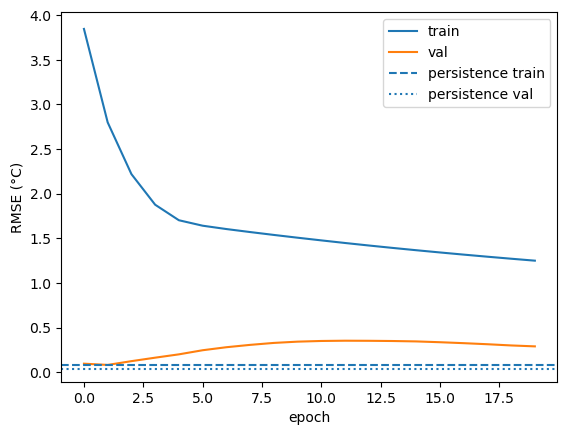

In [ ]:
import matplotlib.pyplot as plt

model.summary()

net_tr = model.predict(X_tr, verbose=0).ravel()
print("net train:", round(rmse(net_tr, y_tr) * sd, 3))
print("persistence train:", round(r_tr, 3))

tr_c = np.sqrt(hist.history["loss"]) * sd
va_c = np.sqrt(hist.history["val_loss"]) * sd

plt.plot(tr_c, label="train")
plt.plot(va_c, label="val")
plt.axhline(r_tr, linestyle="--", label="persistence train")
plt.axhline(r_va, linestyle=":", label="persistence val")
plt.xlabel("epoch")
plt.ylabel("RMSE (°C)")
plt.legend()
plt.show()

In [ ]:
keras.utils.set_random_seed(0)

model = keras.Sequential([
    keras.Input(shape=(15,)),
    keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation="linear"),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

hist = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    batch_size=45,
    epochs=300,
    verbose=0,
)

net_tr = model.predict(X_tr, verbose=0).ravel()
net_va = model.predict(X_va, verbose=0).ravel()
r_net = rmse(net_va, y_va) * sd

print("net train:", round(rmse(net_tr, y_tr) * sd, 3))
print("net val:", round(r_net, 3))
print("skill:", round(1 - r_net / r_va, 3))

net train: 0.09
net val: 0.046
skill: -0.135


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158 (636.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 106 (428.00 B)

net train: 0.09
persistence train: 0.082


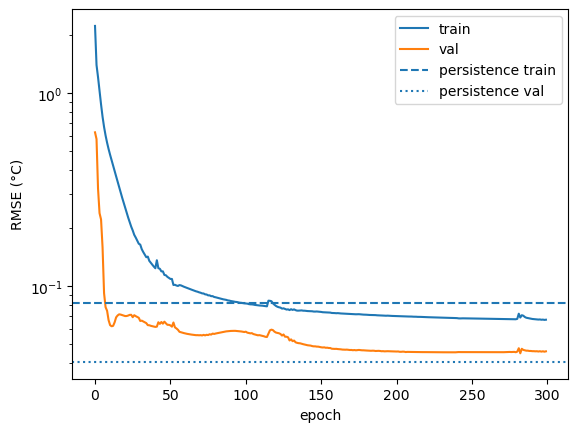

In [ ]:
import matplotlib.pyplot as plt

model.summary()

net_tr = model.predict(X_tr, verbose=0).ravel()
print("net train:", round(rmse(net_tr, y_tr) * sd, 3))
print("persistence train:", round(r_tr, 3))

tr_c = np.sqrt(hist.history["loss"]) * sd
va_c = np.sqrt(hist.history["val_loss"]) * sd

plt.plot(tr_c, label="train")
plt.plot(va_c, label="val")
plt.axhline(r_tr, linestyle="--", label="persistence train")
plt.axhline(r_va, linestyle=":", label="persistence val")
plt.xlabel("epoch")
plt.ylabel("RMSE (°C)")
plt.legend()
plt.yscale("log")
plt.show()

In [24]:
from tensorflow import keras
seg1 = segments[0]
tr2 = seg1.loc[:1639, "t_in"]
va2 = seg1.loc[1655:, "t_in"]

mu2, sd2 = tr2.mean(), tr2.std()
Xt, yt = make_windows(((tr2 - mu2) / sd2).to_numpy(), W)
Xv, yv = make_windows(((va2 - mu2) / sd2).to_numpy(), W)

p_v = rmse(Xv[:, -1], yv) * sd2

keras.utils.set_random_seed(0)
m2 = keras.Sequential([
    keras.Input(shape=(15,)),
    keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation="linear"),
])
m2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")
m2.fit(Xt, yt, batch_size=45, epochs=300, verbose=0)

n_v = rmse(m2.predict(Xv, verbose=0).ravel(), yv) * sd2

print(Xt.shape, Xv.shape)
print("persistence val:", round(p_v, 3))
print("net val:", round(n_v, 3))
print("skill:", round(1 - n_v / p_v, 3))

(1625, 15) (223, 15)
persistence val: 0.06
net val: 0.051
skill: 0.141


## ٢٢/٩ — Overfitting وقراءة منحني الخسارة

In [ ]:
res = []

for s in range(5):
    keras.utils.set_random_seed(s)
    m = keras.Sequential([
        keras.Input(shape=(15,)),
        keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
        keras.layers.Dense(1, activation="linear"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")
    m.fit(Xt, yt, batch_size=45, epochs=300, verbose=0)

    r = rmse(m.predict(Xv, verbose=0).ravel(), yv) * sd2
    res.append((r, 1 - r / p_v))
    print(s, round(r, 4), round(1 - r / p_v, 3))

arr = np.array(res)
print("skill min/max:", round(arr[:, 1].min(), 3), round(arr[:, 1].max(), 3))
print("skill mean:", round(arr[:, 1].mean(), 3))

0 0.0511 0.141
1 0.0682 -0.146
2 0.0566 0.049
3 0.054 0.092
4 0.0854 -0.435
skill min/max: -0.435 0.141
skill mean: -0.06


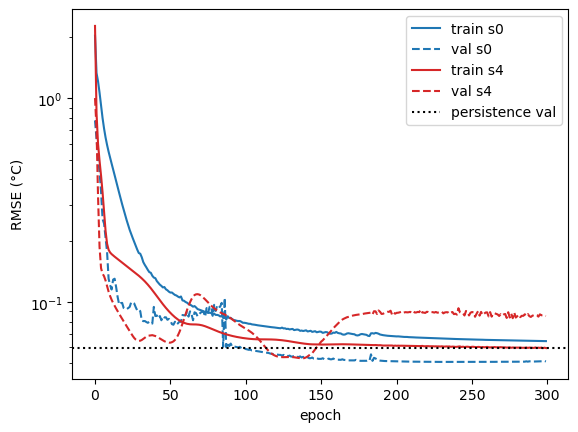

In [ ]:
hs = {}

for s in [0, 4]:
    keras.utils.set_random_seed(s)
    m = keras.Sequential([
        keras.Input(shape=(15,)),
        keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
        keras.layers.Dense(1, activation="linear"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")
    hs[s] = m.fit(Xt, yt, validation_data=(Xv, yv),
                  batch_size=45, epochs=300, verbose=0).history

for s, c in [(0, "C0"), (4, "C3")]:
    plt.plot(np.sqrt(hs[s]["loss"]) * sd2, color=c, label=f"train s{s}")
    plt.plot(np.sqrt(hs[s]["val_loss"]) * sd2, color=c, linestyle="--", label=f"val s{s}")

plt.axhline(p_v, color="k", linestyle=":", label="persistence val")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("RMSE (°C)")
plt.legend()
plt.show()

## ٢٣/٩ — تنظيم و Early Stopping

In [ ]:
res2 = []

for s in range(5):
    keras.utils.set_random_seed(s)
    m = keras.Sequential([
        keras.Input(shape=(15,)),
        keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
        keras.layers.Dense(1, activation="linear"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        restore_best_weights=True,
    )

    h = m.fit(Xt, yt, validation_data=(Xv, yv),
              batch_size=45, epochs=1000, callbacks=[es], verbose=0)

    r = rmse(m.predict(Xv, verbose=0).ravel(), yv) * sd2
    res2.append((r, 1 - r / p_v, es.stopped_epoch, len(h.history["loss"])))
    print(s, round(r, 4), round(1 - r / p_v, 3), "stopped:", es.stopped_epoch)

a2 = np.array(res2)
print("skill min/max:", round(a2[:, 1].min(), 3), round(a2[:, 1].max(), 3))
print("skill mean:", round(a2[:, 1].mean(), 3))

0 0.0509 0.145 stopped: 283
1 0.0654 -0.098 stopped: 91
2 0.0914 -0.535 stopped: 102
3 0.052 0.126 stopped: 420
4 0.0632 -0.062 stopped: 99
skill min/max: -0.535 0.145
skill mean: -0.085


In [ ]:
curves = {}

for s in range(5):
    keras.utils.set_random_seed(s)
    m = keras.Sequential([
        keras.Input(shape=(15,)),
        keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
        keras.layers.Dense(1, activation="linear"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")
    h = m.fit(Xt, yt, validation_data=(Xv, yv),
              batch_size=45, epochs=1000, verbose=0)
    curves[s] = np.array(h.history["val_loss"])
    print("seed", s, "done")


def simulate(v, patience):
    best, best_i = v[0], 0
    for i in range(1, len(v)):
        if v[i] < best:
            best, best_i = v[i], i
        elif i - best_i >= patience:
            break
    return best, best_i


for p in [25, 50, 100, 200, 10**9]:
    sk, st = [], []
    for s in range(5):
        best, i = simulate(curves[s], p)
        r = np.sqrt(best) * sd2
        sk.append(1 - r / p_v)
        st.append(i)
    print(p, "mean:", round(np.mean(sk), 3),
          "min/max:", round(min(sk), 3), round(max(sk), 3),
          "best epochs:", st)

seed 0 done
seed 1 done
seed 2 done
seed 3 done
seed 4 done
25 mean: -0.294 min/max: -0.564 -0.062 best epochs: [52, 41, 8, 29, 49]
50 mean: -0.085 min/max: -0.535 0.145 best epochs: [233, 41, 52, 370, 49]
100 mean: -0.05 min/max: -0.535 0.145 best epochs: [233, 41, 52, 370, 137]
200 mean: 0.153 min/max: 0.111 0.177 best epochs: [233, 804, 938, 997, 137]
1000000000 mean: 0.153 min/max: 0.111 0.177 best epochs: [233, 804, 938, 997, 137]


In [ ]:
res3 = []

for s in range(5):
    keras.utils.set_random_seed(s)
    m = keras.Sequential([
        keras.Input(shape=(15,)),
        keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
        keras.layers.Dense(1, activation="linear"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
    )

    m.fit(Xt, yt, validation_data=(Xv, yv),
          batch_size=45, epochs=1500, callbacks=[es], verbose=0)

    r = rmse(m.predict(Xv, verbose=0).ravel(), yv) * sd2
    res3.append(1 - r / p_v)
    print(s, round(r, 4), round(1 - r / p_v, 3))

a3 = np.array(res3)
print("skill mean:", round(a3.mean(), 3))
print("skill min/max:", round(a3.min(), 3), round(a3.max(), 3))

0 0.0509 0.145
1 0.0494 0.171
2 0.049 0.177
3 0.0495 0.169
4 0.0529 0.111
skill mean: 0.155
skill min/max: 0.111 0.177


In [ ]:
import json

keras.utils.set_random_seed(0)
final = keras.Sequential([
    keras.Input(shape=(15,)),
    keras.layers.Dense(3, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation="linear"),
])
final.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

es = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True,
)

final.fit(Xt, yt, validation_data=(Xv, yv),
          batch_size=45, epochs=1500, callbacks=[es], verbose=0)

r_final = rmse(final.predict(Xv, verbose=0).ravel(), yv) * sd2
print("val rmse:", round(r_final, 4))
print("skill:", round(1 - r_final / p_v, 3))

final.save("t_in_next_step.keras")

meta = {
    "target": "t_in next sample",
    "input_column": "t_in",
    "window": 15,
    "sample_period_s": 2,
    "normalization": "standardization",
    "mu": float(mu2),
    "sd": float(sd2),
    "train_rows": "0-1639 of session 1",
    "val_event": "cold air, rows 1655-1892",
    "val_rmse_c": float(r_final),
    "baseline_persistence_c": float(p_v),
    "seed": 0,
    "keras_version": keras.__version__,
    "valid_range_c": [25.4, 39.1],
    "trained_events": ["hand hold", "hot glass", "cold air"],
    "not_trained_on": "controlled heater",
}

with open("t_in_next_step.meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))

val rmse: 0.0509
skill: 0.145
{
  "target": "t_in next sample",
  "input_column": "t_in",
  "window": 15,
  "sample_period_s": 2,
  "normalization": "standardization",
  "mu": 31.44792682926829,
  "sd": 2.2819627176076422,
  "train_rows": "0-1639 of session 1",
  "val_event": "cold air, rows 1655-1892",
  "val_rmse_c": 0.05087460956240868,
  "baseline_persistence_c": 0.05951975215725439,
  "seed": 0,
  "keras_version": "3.15.1",
  "valid_range_c": [
    25.4,
    39.1
  ],
  "trained_events": [
    "hand hold",
    "hot glass",
    "cold air"
  ],
  "not_trained_on": "controlled heater"
}


In [ ]:
loaded = keras.models.load_model("t_in_next_step.keras")

a = final.predict(Xv, verbose=0).ravel()
b = loaded.predict(Xv, verbose=0).ravel()
print("identical:", np.array_equal(a, b))

with open("t_in_next_step.meta.json") as f:
    mt = json.load(f)

raw = va2.to_numpy()[:15]
truth = va2.to_numpy()[15]

z = (raw - mt["mu"]) / mt["sd"]
pred_z = loaded.predict(z.reshape(1, -1), verbose=0)[0, 0]
pred_c = pred_z * mt["sd"] + mt["mu"]

print("last input:", round(raw[-1], 2))
print("pred:", round(pred_c, 3), "truth:", round(truth, 3))

identical: True
last input: 29.4
pred: 29.404 truth: 29.2


In [25]:
from scipy.optimize import curve_fit

TAU_FAST, TAU_SLOW = 21.0, 236.3

def relax(t, A1, A2, C):
    return A1 * np.exp(-t / TAU_FAST) + A2 * np.exp(-t / TAU_SLOW) + C

raw = va2.to_numpy()
tt = np.arange(len(raw)) * 2.0

def phys_pred(start):
    i0 = start - 1655
    x = tt[i0:i0+15] - tt[i0]
    y = raw[i0:i0+15]
    p0 = [y[0] - y[-1], 0.0, y[-1]]
    popt, _ = curve_fit(relax, x, y, p0=p0, maxfev=50000)
    return relax(tt - tt[i0], *popt), popt

for start, tag in [(1655, "from window start"), (1670, "from event start")]:
    pred, popt = phys_pred(start)
    i0 = start - 1655
    k = max(0, i0 - 15)
    p = pred[k+15:]
    t = raw[k+15:]
    res = t - p
    runs = int(1 + np.sum(np.diff(np.sign(res)) != 0))
    print(tag, "| n:", len(res),
          "| rmse:", round(float(np.sqrt(np.mean(res**2))), 4),
          "| runs:", runs, "/", len(res)//2,
          "| A1,A2,C:", [round(v, 2) for v in popt])

from window start | n: 223 | rmse: 4.0782 | runs: 1 / 111 | A1,A2,C: [np.float64(0.43), np.float64(-3.84), np.float64(32.72)]
from event start | n: 223 | rmse: 5.5604 | runs: 10 / 111 | A1,A2,C: [np.float64(-0.47), np.float64(12.46), np.float64(17.23)]


In [26]:
C_FIX = float(seg1.loc[1600:1660, "t_in"].mean())

def relax2(t, A1, A2):
    return A1 * np.exp(-t / TAU_FAST) + A2 * np.exp(-t / TAU_SLOW) + C_FIX

i0 = 1670 - 1655
x = tt[i0:i0+15] - tt[i0]
popt, _ = curve_fit(relax2, x, raw[i0:i0+15], p0=[-1.0, -3.0], maxfev=50000)

pred = relax2(tt - tt[i0], *popt)
res = raw[i0+15:] - pred[i0+15:]
runs = int(1 + np.sum(np.diff(np.sign(res)) != 0))

print("C_FIX:", round(C_FIX, 2), "A1,A2:", [round(v, 2) for v in popt])
print("rmse:", round(float(np.sqrt(np.mean(res**2))), 4),
      "| runs:", runs, "/", len(res)//2)

C_FIX: 29.0 A1,A2: [np.float64(1.59), np.float64(-1.24)]
rmse: 1.5935 | runs: 1 / 104
